In [1]:
import sys

sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pickle

import keras

import bayesflow as bf

from dmc import dmc_helpers
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


## Load Empirical Data

In [2]:
# load narrow and wide data
narrow_data = pd.read_csv('../empirical_data/experiment_data_narrow.csv')
wide_data = pd.read_csv('../empirical_data/experiment_data_wide.csv')

# participant IDs that should be used for prior updating (randomly sampled):
train_idx = np.array([1761, 5281,  845, 1824, 5575, 8755, 8026, 8704, 7813, 1597, 7756,
       7624, 1108,  837, 7828, 6055,  833, 1821,  985, 1582, 8311, 8785,
       3286, 4264, 6583, 3487, 6427, 1430, 6361, 5815, 6262, 5332,
       1614, 7939, 6214, 6253])

In [3]:
# exclude training IDs
narrow_data = narrow_data[~narrow_data['participant'].isin(train_idx)]
wide_data = wide_data[~wide_data['participant'].isin(train_idx)]

## Load Approximator

First, we load the approximator for the initial priors sdr estimated network and sample from the posterior seperately for the experimental conditions:

In [4]:
network_name = 'initial_priors_sdr_estimated'

approximator = keras.saving.load_model("../training_checkpoints/" + network_name + ".keras")

/home/administrator/miniforge3/envs/bf_new/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 159 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Posterior Samples Narrow Condition

In [5]:
post_samples_narrow = dmc_helpers.fit_empirical_data(narrow_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

Sampling posteriors:   8%|▊         | 3/36 [00:03<00:35,  1.08s/it]

[ID 808] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0026553881511746646. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 36/36 [00:32<00:00,  1.09it/s]


## Posterior Samples Wide Condition

In [6]:
post_samples_wide = dmc_helpers.fit_empirical_data(wide_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

Sampling posteriors:  28%|██▊       | 10/36 [00:13<00:30,  1.18s/it]

[ID 275] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0018050166112955623. Please check the coding of congruency conditions.


Sampling posteriors:  47%|████▋     | 17/36 [00:18<00:15,  1.19it/s]

[ID 3988] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.005174194991055481. Please check the coding of congruency conditions.


Sampling posteriors:  50%|█████     | 18/36 [00:19<00:15,  1.18it/s]

[ID 4222] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.00423551067323491. Please check the coding of congruency conditions.


Sampling posteriors:  58%|█████▊    | 21/36 [00:21<00:11,  1.28it/s]

[ID 5803] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0037004545454545346. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 36/36 [00:33<00:00,  1.08it/s]


## Standardized Mean Differences

After sampling from the posterior for both experimental conditions, we can compute the standardized mean differences as follows:

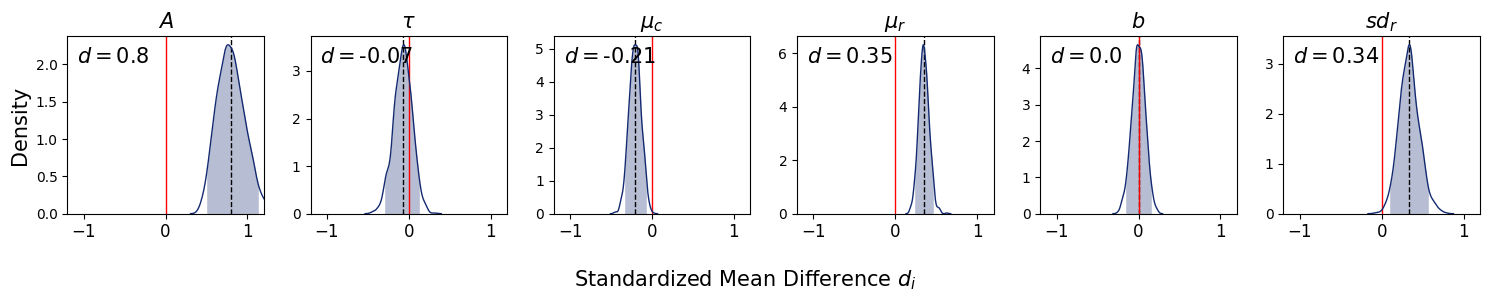

In [7]:
data, fig = dmc_helpers.smd_samples(post_samples_narrow, 
                                    post_samples_wide, 
                                    param_names=("A", "tau", "mu_c", "mu_r", "b", "sd_r"), 
                                    num_samples=1000, 
                                    id_name='participant', 
                                    hdi_color='white', 
                                    sharex=False)

## Updated Priors sdr estimated

We apply the same code to the remaining networks:

Sampling posteriors:   8%|▊         | 3/36 [00:02<00:30,  1.07it/s]

[ID 808] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0026553881511746646. Please check the coding of congruency conditions.


Sampling posteriors:  28%|██▊       | 10/36 [00:08<00:21,  1.21it/s]

[ID 275] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0018050166112955623. Please check the coding of congruency conditions.


Sampling posteriors:  47%|████▋     | 17/36 [00:17<00:23,  1.22s/it]

...

Sampling posteriors:  50%|█████     | 18/36 [00:18<00:20,  1.14s/it]

[ID 4222] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.00423551067323491. Please check the coding of congruency conditions.


Sampling posteriors:  58%|█████▊    | 21/36 [00:20<00:13,  1.14it/s]

[ID 5803] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0037004545454545346. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 36/36 [00:50<00:00,  1.39s/it]


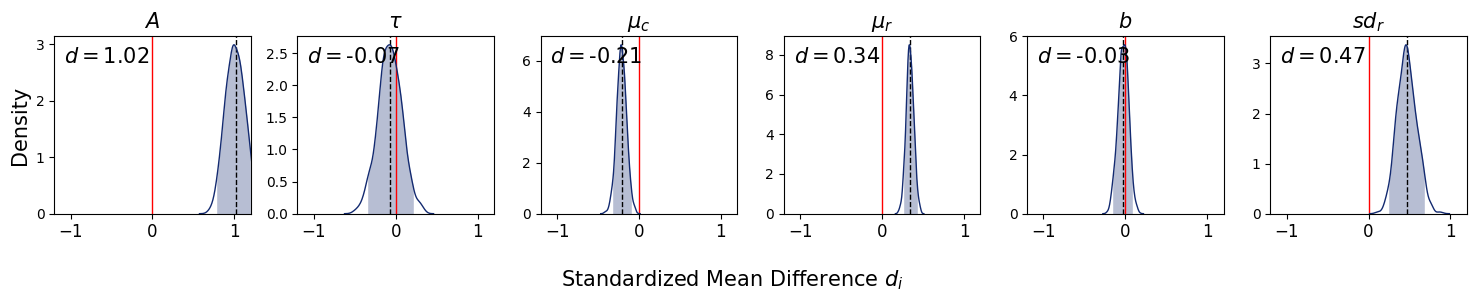

In [8]:
network_name = 'updated_priors_sdr_estimated'

approximator = keras.saving.load_model("../training_checkpoints/" + network_name + ".keras")

post_samples_narrow = dmc_helpers.fit_empirical_data(narrow_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

post_samples_wide = dmc_helpers.fit_empirical_data(wide_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

data, fig = dmc_helpers.smd_samples(post_samples_narrow, 
                                    post_samples_wide, 
                                    param_names=("A", "tau", "mu_c", "mu_r", "b", "sd_r"), 
                                    num_samples=1000, 
                                    id_name='participant', 
                                    hdi_color='white', 
                                    sharex=False)

Sampling posteriors:   8%|▊         | 3/36 [00:02<00:30,  1.10it/s]

[ID 808] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0026553881511746646. Please check the coding of congruency conditions.


Sampling posteriors:  28%|██▊       | 10/36 [00:07<00:21,  1.23it/s]

[ID 275] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0018050166112955623. Please check the coding of congruency conditions.


Sampling posteriors:  47%|████▋     | 17/36 [00:14<00:19,  1.04s/it]

...

Sampling posteriors:  50%|█████     | 18/36 [00:16<00:19,  1.09s/it]

[ID 4222] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.00423551067323491. Please check the coding of congruency conditions.


Sampling posteriors:  58%|█████▊    | 21/36 [00:19<00:14,  1.03it/s]

[ID 5803] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0037004545454545346. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 36/36 [00:29<00:00,  1.23it/s]


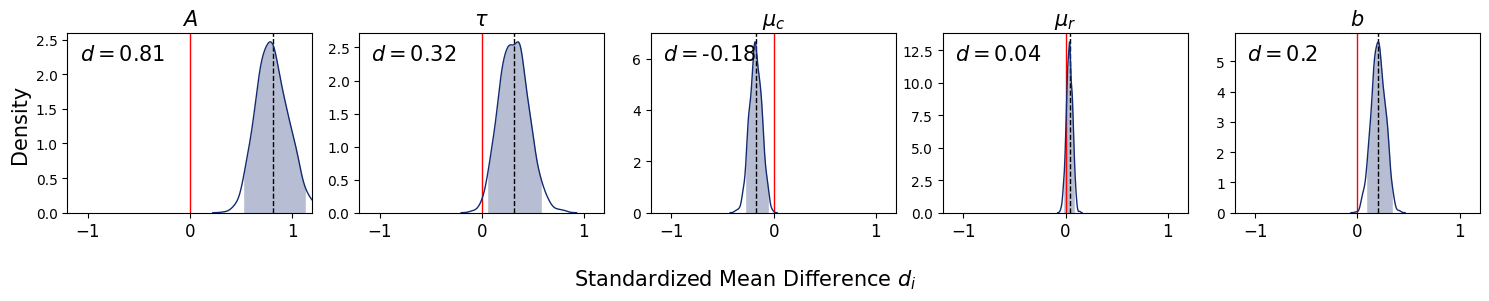

In [9]:
network_name = 'initial_priors_sdr_fixed'

approximator = keras.saving.load_model("../training_checkpoints/" + network_name + ".keras")

post_samples_narrow = dmc_helpers.fit_empirical_data(narrow_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

post_samples_wide = dmc_helpers.fit_empirical_data(wide_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

data, fig = dmc_helpers.smd_samples(post_samples_narrow, 
                                    post_samples_wide, 
                                    param_names=("A", "tau", "mu_c", "mu_r", "b"), 
                                    num_samples=1000, 
                                    id_name='participant', 
                                    hdi_color='white', 
                                    sharex=False)

Sampling posteriors:   8%|▊         | 3/36 [00:02<00:28,  1.16it/s]

[ID 808] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0026553881511746646. Please check the coding of congruency conditions.


Sampling posteriors:  28%|██▊       | 10/36 [00:14<00:27,  1.06s/it]

[ID 275] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0018050166112955623. Please check the coding of congruency conditions.


Sampling posteriors:  47%|████▋     | 17/36 [00:20<00:16,  1.16it/s]

...

Sampling posteriors:  50%|█████     | 18/36 [00:21<00:15,  1.16it/s]

[ID 4222] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.00423551067323491. Please check the coding of congruency conditions.


Sampling posteriors:  58%|█████▊    | 21/36 [00:23<00:12,  1.17it/s]

[ID 5803] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0037004545454545346. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 36/36 [00:41<00:00,  1.15s/it]


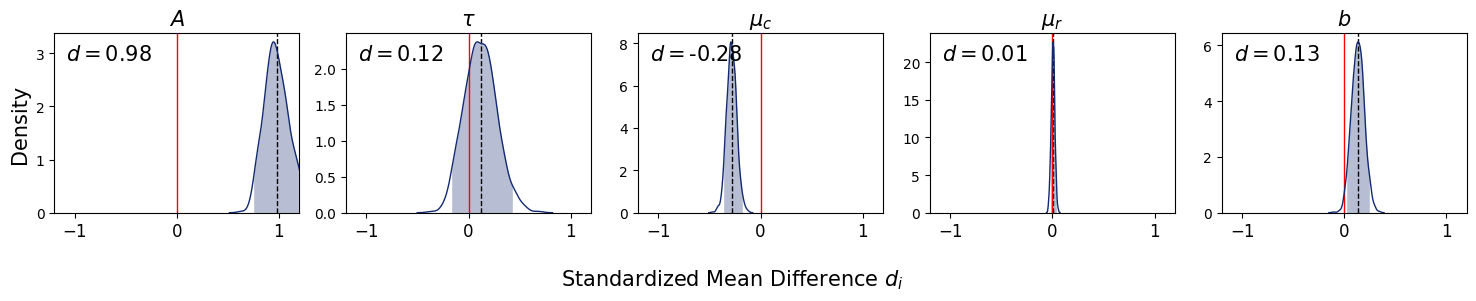

In [10]:
network_name = 'updated_priors_sdr_fixed'

approximator = keras.saving.load_model("../training_checkpoints/" + network_name + ".keras")

post_samples_narrow = dmc_helpers.fit_empirical_data(narrow_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

post_samples_wide = dmc_helpers.fit_empirical_data(wide_data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency_num')

data, fig = dmc_helpers.smd_samples(post_samples_narrow, 
                                    post_samples_wide, 
                                    param_names=("A", "tau", "mu_c", "mu_r", "b"), 
                                    num_samples=1000, 
                                    id_name='participant', 
                                    hdi_color='white', 
                                    sharex=False)
